# Week 7 – Day 1 (3 Hours)

# Session 1 (90 Minutes)

# From Modeling to Model Evaluation
## Model Evaluation Foundations

---

# Session Overview

In previous sessions, we learned how to build machine learning models using several classical algorithms. However, building a model is only the first step of a successful machine learning project.

A natural question arises:

> **How do we know whether a model is actually good?**

Today's session answers this question by introducing the fundamental concepts of model evaluation. Students will learn why evaluation is essential, which metrics should be used for different machine learning tasks, and why accuracy alone is often misleading.

---

# Learning Objectives

By the end of this session, students will be able to:

- Recall the purpose of the classical machine learning models introduced previously.
- Distinguish between regression, classification, and clustering tasks.
- Explain why model evaluation is necessary.
- Select appropriate evaluation metrics for regression and classification problems.
- Interpret Confusion Matrix, Accuracy, Precision, Recall, and F1-score.
- Recognize situations where Accuracy is not an appropriate metric.
- Develop intuition for evaluating machine learning models before learning advanced validation techniques.

---

# Session Roadmap

| Time | Topic |
|------|-------|
| 00:00 – 00:20 | Review of Week 6 Models |
| 00:20 – 00:55 | Model Evaluation Metrics |
| 00:55 – 01:15 | Why Accuracy Is Not Enough |
| 01:15 – 01:30 | Summary & Discussion |

---

# Part 1 — Review of Week 6 Models (20 Minutes)

## Why Review?

Before learning how to evaluate a model, we must first remember what kinds of models we have already learned.

Machine learning algorithms solve different types of problems, and each problem requires different evaluation techniques.

---

# Machine Learning Tasks

```
Machine Learning

├── Supervised Learning
│      ├── Regression
│      └── Classification
│
└── Unsupervised Learning
       └── Clustering
```

---

# Linear Regression

## Purpose

Linear Regression is a **regression algorithm** used to predict continuous numerical values.

Examples include:

- House price prediction
- Sales forecasting
- Temperature prediction
- Energy consumption estimation

---

## Core Idea

Linear Regression learns a straight-line relationship between the input features and the target variable.

```
Input Features

↓

Linear Equation

↓

Predicted Value
```

---

## Strengths

- Simple
- Fast
- Easy to interpret
- Strong baseline regression model

---

## Limitations

- Assumes a linear relationship
- Sensitive to outliers
- Cannot capture complex nonlinear patterns

---

## Linear Regression Review — Example

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Load dataset
data = fetch_california_housing()

X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²  :", r2_score(y_test, y_pred))


MAE : 0.5332001304956989
MSE : 0.5558915986952425
RMSE: 0.7455813830127751
R²  : 0.5757877060324521


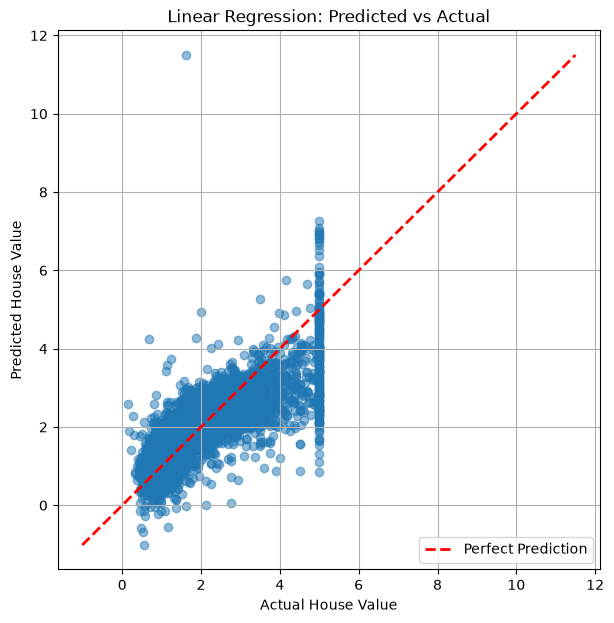

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize predictions vs. actual values
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Linear Regression: Predicted vs Actual")
plt.legend()
plt.grid(True)

plt.show()

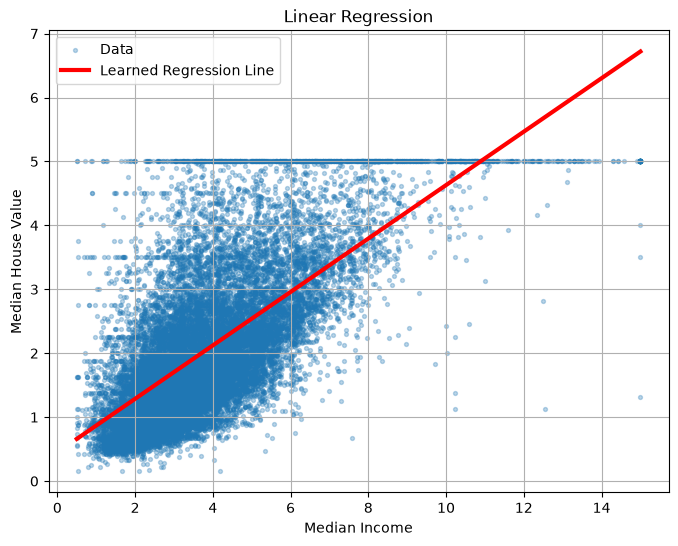

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
data = fetch_california_housing()

# Use only one feature: Median Income
X = data.data[:, [0]]      # MedInc
y = data.target

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Sort points for plotting
idx = np.argsort(X[:, 0])

plt.figure(figsize=(8, 6))

plt.scatter(
    X,
    y,
    s=8,
    alpha=0.3,
    label="Data"
)

plt.plot(
    X[idx],
    y_pred[idx],
    color="red",
    linewidth=3,
    label="Learned Regression Line"
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

---

### Expected Discussion

Ask students:

- Is this a regression or classification problem?
- What type of values does the model predict?
- Why don't we use Accuracy for Linear Regression?
- Which metric should we use instead?
- What does an R² score close to 1 indicate?

---


```
Dataset
    ↓
Train/Test Split
    ↓
Linear Regression
    ↓
Prediction
    ↓
MSE / RMSE / R²
```

---

## Transition to Logistic Regression

Both algorithms have **"Regression"** in their names, but they solve different problems.

| Linear Regression | Logistic Regression |
|-------------------|---------------------|
| Regression | Classification |
| Predicts continuous values | Predicts class probabilities |
| Output: Any real number | Output: Probability (0–1) |
| Metrics: MSE, RMSE, R² | Metrics: Accuracy, Precision, Recall, F1-score |

This distinction is important because the **evaluation metric depends on the type of machine learning task**, not on the algorithm's name.

# Logistic Regression

## Purpose

Logistic Regression is a **classification algorithm** used to predict discrete categories.

Examples include:

- Spam detection
- Disease diagnosis
- Customer churn prediction
- Fraud detection

---

## Core Idea

Instead of predicting continuous values, Logistic Regression estimates the probability that an observation belongs to a particular class.

```
Input Features

↓

Linear Combination

↓

Sigmoid Function

↓

Probability

↓

Class Prediction
```

---

## Strengths

- Simple
- Fast
- Interpretable
- Strong baseline classifier

---

## Limitations

- Assumes approximately linear decision boundaries
- Limited performance for highly complex problems

---

In [4]:
# Logistic Regression Review — Example

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create the model
model = LogisticRegression(max_iter=5000)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.9649122807017544

Confusion Matrix
[[39  3]
 [ 1 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



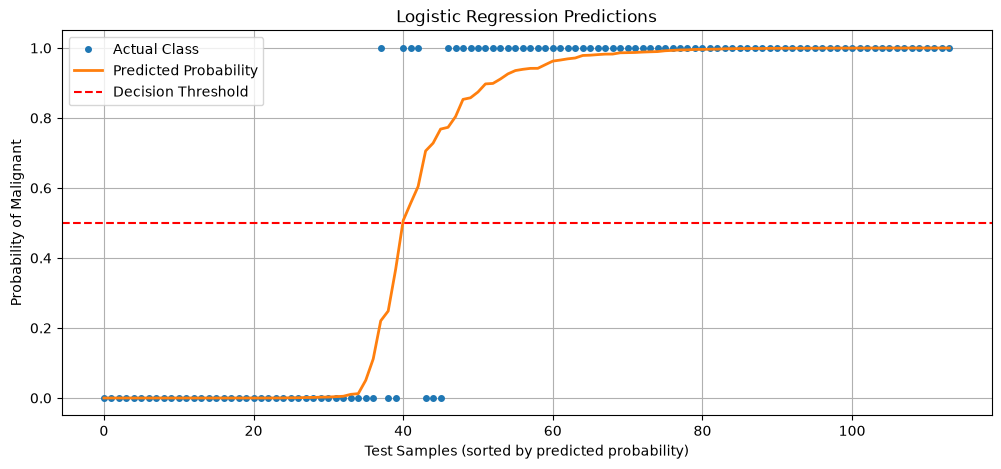

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Predicted probability of the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Sort by predicted probability
idx = np.argsort(y_prob)

plt.figure(figsize=(12, 5))

plt.plot(
    y_test[idx],
    "o",
    label="Actual Class",
    markersize=4
)

plt.plot(
    y_prob[idx],
    linewidth=2,
    label="Predicted Probability"
)

plt.axhline(
    y=0.5,
    color="red",
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Test Samples (sorted by predicted probability)")
plt.ylabel("Probability of Malignant")
plt.title("Logistic Regression Predictions")

plt.legend()
plt.grid(True)

plt.show()

### Expected Discussion

Ask students:

- Which algorithm did we use?
- Is this a classification or regression problem?
- What is the target variable?
- What does the `predict()` function return?
- Is Accuracy alone enough to evaluate this model?


```
Dataset
    ↓
Train/Test Split
    ↓
Logistic Regression
    ↓
Prediction
    ↓
Evaluation
```

# K-Nearest Neighbors Regression (KNN Regression)

## Purpose

K-Nearest Neighbors (KNN) Regression is a **regression algorithm** used to predict continuous numerical values based on the values of nearby training samples.

Examples include:

- House price prediction
- Temperature estimation
- Sales forecasting
- Traffic volume prediction

---

## Core Idea

Instead of learning a mathematical equation, KNN Regression finds the **K nearest training samples** and predicts the target value by averaging their outputs.

```
Input Sample

↓

Find K Nearest Neighbors

↓

Average Their Target Values

↓

Predicted Value
```

---

## Strengths

- Simple and intuitive
- No explicit training phase
- Can model nonlinear relationships
- Effective for small datasets

---

## Limitations

- Prediction can be slow on large datasets
- Sensitive to the choice of **K**
- Sensitive to feature scaling
- Performance decreases in high-dimensional spaces

---

$$d = \sqrt{(x^1_1-x^2_1)^2 + (x^1_2-x^2_2)^2}$$

## Metric Learning

$$d = \alpha (x^1_1-x^2_1)^2 + \beta (x^1_2-x^2_2)^2$$ 

## KNN Regression Review — Example

In [27]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Load dataset
data = fetch_california_housing()

print(X.shape)

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create model
model = KNeighborsRegressor(n_neighbors=1)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²  :", r2_score(y_test, y_pred))


(20640, 8)
MAE : 0.5361632582364342
MSE : 0.6690121695201793
RMSE: 0.8179316411046703
R²  : 0.48946307555198154


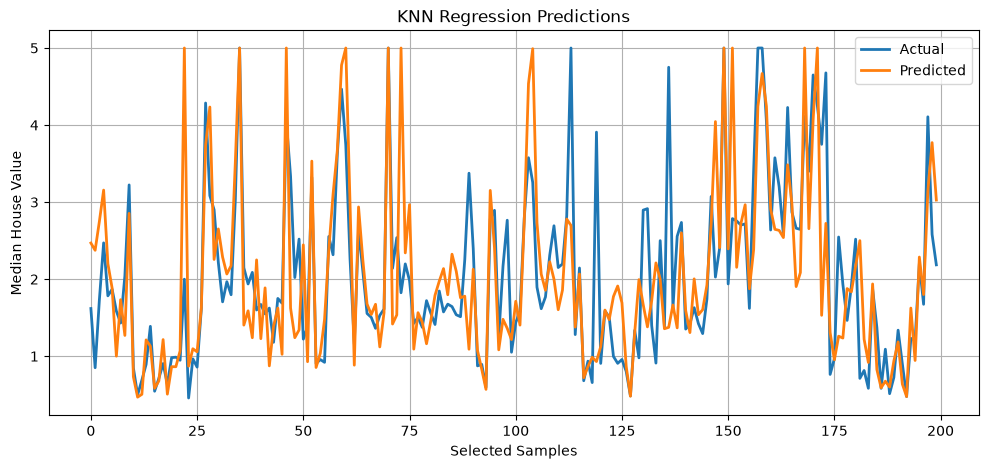

In [28]:
np.random.seed(42)

X_scaled = scaler.transform(X)
y_all_pred = model.predict(X_scaled)

indices = np.random.choice(
    len(y),
    size=200,
    replace=False
)

indices = np.sort(indices)

plt.figure(figsize=(12,5))

plt.plot(
    y[indices],
    linewidth=2,
    label="Actual"
)

plt.plot(
    y_all_pred[indices],
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Selected Samples")
plt.ylabel("Median House Value")
plt.title("KNN Regression Predictions")
plt.legend()
plt.grid(True)

plt.show()

---

### Expected Discussion

Ask students:

- What does the value **K = 5** represent?
- Why should features be standardized?
- What happens if K becomes very large?
- Which evaluation metrics are appropriate?

---


> Emphasize that KNN Regression is a **lazy learning algorithm**.

> Unlike Linear Regression, it does not learn an equation during training. Instead, it stores the training data and performs computation only when making predictions.

---

# K-Nearest Neighbors Classification (KNN Classifier)

## Purpose

K-Nearest Neighbors (KNN) Classification is a **classification algorithm** that predicts the class of a sample based on the classes of its nearest neighbors.

Examples include:

- Handwritten digit recognition
- Medical diagnosis
- Customer segmentation
- Species classification

---

## Core Idea

The algorithm finds the **K nearest training samples** and assigns the class that appears most frequently among them.

```
Input Sample

↓

Find K Nearest Neighbors

↓

Majority Vote

↓

Predicted Class
```

---

## Strengths

- Easy to understand
- No training phase
- Naturally handles nonlinear decision boundaries
- Effective on small datasets

---

## Limitations

- Slow predictions for large datasets
- Sensitive to feature scaling
- Choosing the right value of **K** is important
- Performance decreases in high-dimensional spaces

---

## KNN Classification Review — Example

In [29]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create model
model = KNeighborsClassifier(n_neighbors=5)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.956140350877193

Confusion Matrix
[[39  3]
 [ 2 70]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Probability of the positive class
y_prob = model.predict_proba(X_test)[:, 1]
# y_prob = model.predict(X_test)[:, 1]

# Sort by predicted probability
idx = np.argsort(y_prob)

plt.figure(figsize=(12, 5))

# Actual classes
plt.scatter(
    range(len(idx)),
    y_test[idx],
    s=20,
    color="black",
    alpha=0.7,
    label="Actual Class"
)

# Predicted probabilities
plt.plot(
    y_prob[idx],
    linewidth=2,
    color="tab:blue",
    label="Predicted Probability"
)

# Decision threshold
plt.axhline(
    0.5,
    color="red",
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Test Samples (sorted by predicted probability)")
plt.ylabel("Probability of Positive Class")
plt.title("K-Nearest Neighbors Classification")

plt.grid(True)
plt.legend()

plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

---

### Expected Discussion

Ask students:

- Why do we scale the features before applying KNN?
- What happens if **K = 1**?
- What happens if **K** becomes very large?
- Which evaluation metrics are appropriate for this problem?

---


> Unlike Logistic Regression or Decision Trees, KNN performs **no model learning** during training.

> The "training" phase simply stores the dataset. All computation happens during prediction by measuring distances between the new sample and the training data.

---

## Transition to Decision Trees

Both KNN and Decision Trees can solve **classification problems**, but they work very differently.

| KNN Classification | Decision Tree |
|--------------------|---------------|
| Instance-based learning | Rule-based learning |
| Stores training samples | Learns decision rules |
| Uses distance between samples | Uses feature splits |
| Requires feature scaling | Usually does not require scaling |
| Prediction can be slow | Prediction is very fast |
| Sensitive to the choice of K | Sensitive to tree depth and pruning |

In the next section, we review **Decision Trees**, which make predictions by learning a sequence of decision rules instead of comparing distances between samples.

# Decision Tree

## Purpose

Decision Trees solve both:

- Classification
- Regression

problems.

---

## Core Idea

The model repeatedly asks questions that split the dataset into increasingly homogeneous groups.

```
             Root

          Age > 30?

         /         \

      Yes          No

   Income?

      ...

Prediction
```

---

## Strengths

- Easy to understand
- Easy to visualize
- Handles nonlinear relationships
- Requires little preprocessing

---

## Weaknesses

- Easily overfits
- Sensitive to noisy data
- Small data changes may produce different trees

---

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy :", model.score(X_test, y_test))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Training Accuracy: 1.0
Testing Accuracy : 0.9122807017543859

Confusion Matrix
[[39  3]
 [ 7 65]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



---

## Visualizing the Decision Tree

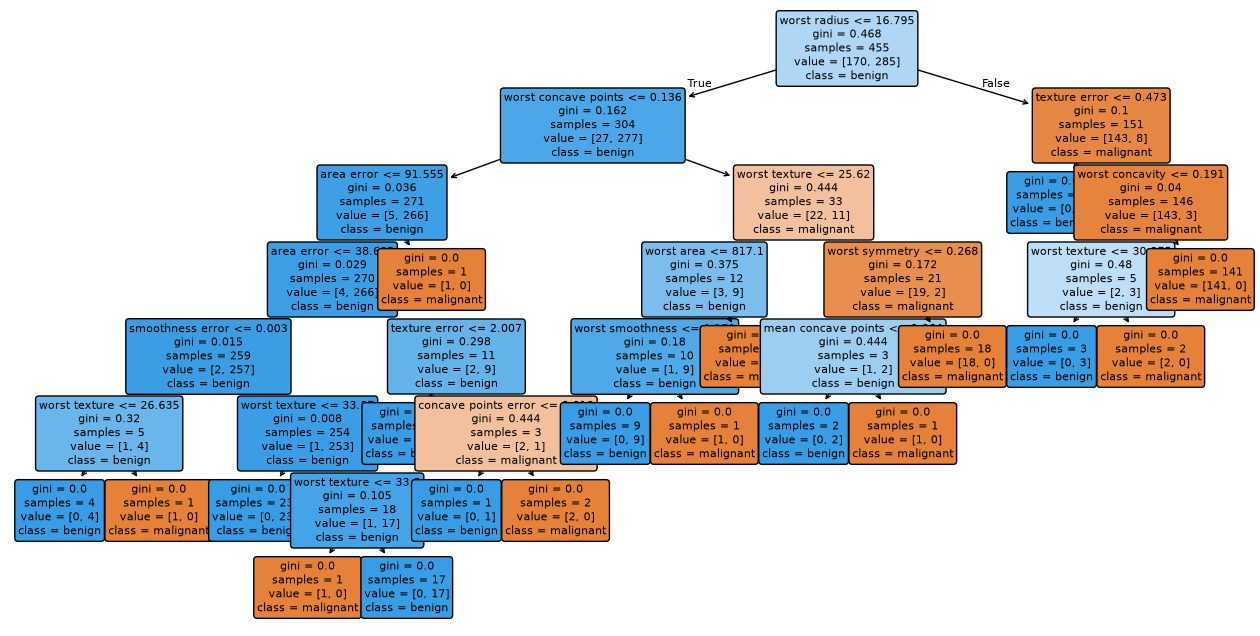

In [11]:
plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

---

### Expected Discussion

Ask students:

- Which feature is selected at the root of the tree?
- What does each split represent?
- Why is the Training Accuracy often higher than the Testing Accuracy?
- Is this tree likely to overfit?
- How might we make this tree simpler?

---



---

## K-Means Clustering Review — Example

Cluster Centers:
[[ 4.73821371  1.91399279]
 [-8.65017946  7.48183793]
 [-7.02523244 -6.90932713]
 [-2.62081897  9.10806483]]


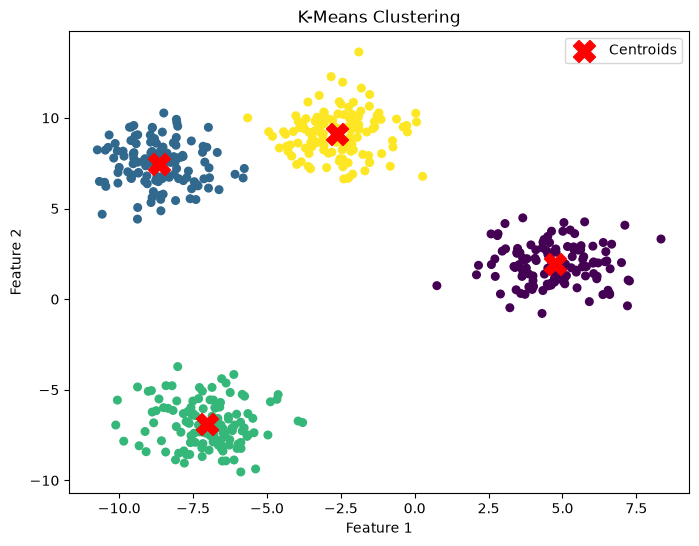

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate synthetic dataset
X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

# Create K-Means model
model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Train the model and assign cluster labels
labels = model.fit_predict(X)

# Display cluster centers
print("Cluster Centers:")
print(model.cluster_centers_)

# Visualize the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=30,
    cmap="viridis"
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

plt.show()

# K-Means Clustering — Pseudocode

```text
Input:
    X = {x₁, x₂, ..., xₙ}      // Dataset
    K                          // Number of clusters
    max_iter                   // Maximum iterations

Output:
    K clusters
    K centroids

----------------------------------------------------

1. Randomly initialize K centroids.

2. Repeat until convergence or max_iter reached:

    Assignment Step:
        For each data point x in X:
            Compute the distance from x to every centroid.
            Assign x to the nearest centroid.

    Update Step:
        For each cluster:
            Compute the mean of all assigned points.
            Move the centroid to this mean.

    If no centroid changes:
        Stop.

3. Return the clusters and centroids.
```

---

## More Detailed Version

```text
KMEANS(X, K)

    Choose K random centroids

    repeat

        // Assignment step
        for each point x in X do

            min_distance ← ∞
            assigned_cluster ← -1

            for each centroid c do

                d ← Distance(x, c)

                if d < min_distance then
                    min_distance ← d
                    assigned_cluster ← c
                end if

            end for

            Assign x to assigned_cluster

        end for


        // Update step
        for each cluster i do

            centroid[i] ← Mean(all points in cluster i)

        end for

    until centroids do not change

    return centroids and clusters
```

---

## Time Complexity

```text
n = number of data points
K = number of clusters
d = number of features
t = number of iterations

Time Complexity:

O(n × K × d × t)
```

---

### Expected Discussion

Ask students:

- Why don't we have a target variable (`y`)?
- What does each color represent?
- What do the red **X** markers represent?
- How did the algorithm determine the cluster assignments?
- What would happen if we changed `n_clusters` from **4** to **3** or **6**?

---


---

## Transition to Model Evaluation

Notice that we cannot calculate **Accuracy**, **Precision**, or **Recall** because there are **no ground-truth labels**.

This raises an important question:

> **How do we evaluate a clustering algorithm?**

In **Week 7 – Day 2**, we will answer this question by introducing:

- Elbow Method
- Inertia (Within-Cluster Sum of Squares)
- Silhouette Score

These metrics help us determine whether our clusters are meaningful and how many clusters should be used.

## Transition to Model Evaluation

Unlike previous algorithms, Decision Trees can become extremely complex if they are allowed to grow without restrictions.

This naturally leads to an important question:

> **If a model achieves 100% training accuracy, can we trust it?**

The answer is **not always**.

In the next section, we will learn about **Overfitting**, **Underfitting**, and why evaluating a model on the training data alone can be misleading.

# K-Means Clustering

## Purpose

K-Means is an **unsupervised learning algorithm**.

Unlike classification, it does not use labels.

Instead, it discovers natural groups within data.

---

## Core Idea

```
Random Centers

↓

Assign Samples

↓

Update Centers

↓

Repeat

↓

Stable Clusters
```

---

## Applications

- Customer segmentation
- Image compression
- Document clustering
- Recommendation systems

---

## Weaknesses

- Must choose K beforehand
- Sensitive to initialization
- Assumes roughly spherical clusters

---

# Quick Classroom Discussion

Ask students:

> Which algorithm would you choose for:

- Predicting house prices?
- Detecting fraudulent transactions?
- Segmenting customers?
- Predicting whether a student passes an exam?

Encourage discussion before revealing the answers.

---

# Part 2 — Why Model Evaluation Matters (10 Minutes)

Suppose two students build two different machine learning models.

Model A reports

```
Accuracy = 98%
```

Model B reports

```
Accuracy = 92%
```

Question:

> Is Model A necessarily better?

Most beginners immediately answer:

> Yes.

Unfortunately, the answer is:

> **Not always.**

To understand why, we must first understand how models are evaluated.

---

# What Does "Good Model" Mean?

A good model should:

- Make accurate predictions.
- Generalize to unseen data.
- Produce consistent performance.
- Be robust against noise.
- Solve the intended business problem.

Evaluation metrics help us measure these properties objectively.

---

# Part 3 — Evaluation Metrics (25 Minutes)

Machine learning tasks require different evaluation metrics.

```
Regression

↓

Continuous Output

↓

MSE
RMSE
R²
```

```
Classification

↓

Discrete Classes

↓

Confusion Matrix

↓

Accuracy

Precision

Recall

F1-score
```

---

# Regression Metrics

## Mean Squared Error (MSE)

Measures the average squared prediction error.

$$
MSE=
\frac1n
\sum_{i=1}^{n}(y_i-\hat y_i)^2
$$

Characteristics:

- Penalizes large errors.
- Always non-negative.
- Lower values are better.

---

## Root Mean Squared Error (RMSE)

$$
RMSE=\sqrt{MSE}
$$

Advantages:

- Same units as the target variable.
- Easier to interpret.

---


# R-Squared (R²)

## Definition

**R-Squared (R²)**, also called the **coefficient of determination**, measures how much of the variation in the target variable is explained by a regression model.

The formula is:

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

where:

- $SS_{res}$ = Residual Sum of Squares (unexplained error)
- $SS_{tot}$ = Total Sum of Squares (total variation in the data)

---

# 1. Residual Sum of Squares (SS_res)

## Definition

The **Residual Sum of Squares** measures the difference between the actual target values and the values predicted by the model.

$$
SS_{res}=\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

Where:

| Symbol | Meaning |
|---|---|
| $y_i$ | Actual target value |
| $\hat{y_i}$ | Model prediction |
| $n$ | Number of samples |

In simple terms:

> **SS_res represents the error that the model cannot explain.**

A smaller $SS_{res}$ means the predictions are closer to the actual values.

---

## Example

Suppose a model predicts house prices:

| Actual Price ($y$) | Predicted Price ($\hat{y}$) | Error | Squared Error |
|---|---|---|---|
| 10 | 9 | 1 | 1 |
| 15 | 14 | 1 | 1 |
| 20 | 18 | 2 | 4 |

Therefore:

$$
SS_{res}=1+1+4=6
$$

The model has a total prediction error of **6**.

---

# 2. Total Sum of Squares ($SS_{tot}$)

## Definition

The **Total Sum of Squares** measures the total variation of the target values around their mean.

$$
SS_{tot}=\sum_{i=1}^{n}(y_i-\bar{y})^2
$$

Where:

| Symbol | Meaning |
|---|---|
| $y_i$ | Actual target value |
| $\bar{y}$ | Mean of all target values |

In simple terms:

> **SS_tot represents how much the target values vary naturally before applying any model.**

---

## Example

Target values:

$$
y=[10,15,20]
$$

Mean:

$$
\bar{y}=15
$$

Calculation:

| Actual ($y$) | Mean ($\bar{y}$) | Difference | Squared Difference |
|---|---|---|---|
| 10 | 15 | -5 | 25 |
| 15 | 15 | 0 | 0 |
| 20 | 15 | 5 | 25 |

Therefore:

$$
SS_{tot}=25+0+25=50
$$

The total variation in the data is **50**.

---

# Relationship Between SS_res and SS_tot

The total variation can be divided into two parts:

$$
SS_{tot}=SS_{res}+SS_{explained}
$$

Where:

| Term | Meaning |
|---|---|
| $SS_{tot}$ | Total variation in the target values |
| $SS_{res}$ | Variation not explained by the model |
| $SS_{explained}$ | Variation explained by the model |

Therefore:

$$
R^2=
1-\frac{\text{Unexplained Variation}}
{\text{Total Variation}}
$$

---

# Example Calculation of R²

Assume:

$$
SS_{tot}=10000
$$

and:

$$
SS_{res}=2000
$$

Then:

$$
R^2=1-\frac{2000}{10000}
$$

$$
R^2=1-0.2
$$

$$
R^2=0.8
$$

Interpretation:

> The model explains **80% of the variation** in the target variable.

The remaining:

$$
1-0.8=0.2
$$

or **20%** is unexplained error.

---

# Why R² = 0 Means Predicting the Mean

A simple baseline model predicts the average value for every sample:

$$
\hat{y_i}=\bar{y}
$$

In this case:

$$
SS_{res}=SS_{tot}
$$

Therefore:

$$
R^2=1-\frac{SS_{tot}}{SS_{tot}}
$$

$$
R^2=0
$$

Meaning:

> The model performs no better than simply predicting the average target value.

---

# Why R² Can Be Negative

Normally:

$$
0 \leq R^2 \leq 1
$$

However, R² can become negative when:

$$
SS_{res}>SS_{tot}
$$

which gives:

$$
R^2<0
$$

This means:

> The model performs worse than the baseline model that always predicts the mean.

This can happen when:

- The model is poorly trained.
- The features do not contain useful information.
- The model is applied to data outside its training distribution.

---

# Summary

| Concept | Formula | Meaning |
|---|---|---|
| $SS_{res}$ | $\sum(y_i-\hat{y_i})^2$ | Model prediction error |
| $SS_{tot}$ | $\sum(y_i-\bar{y})^2$ | Total variation in the data |
| $R^2$ | $1-\frac{SS_{res}}{SS_{tot}}$ | Percentage of variation explained by the model |

## Interpretation of R²

| R² Value | Meaning |
|---|---|
| 1 | Perfect predictions |
| 0 | Same performance as predicting the mean |
| < 0 | Worse than predicting the mean |


---

# Classification Metrics

Instead of measuring numerical error,

we compare predicted labels with actual labels.

---

# Confusion Matrix

Example:

| | Predicted Positive | Predicted Negative |
|---|---:|---:|
| Actual Positive | TP | FN |
| Actual Negative | FP | TN |

---

## True Positive (TP)

Correct positive prediction.

Example:

Patient has disease.

Model predicts disease.

---

## False Positive (FP)

Incorrect positive prediction.

Model predicts disease.

Patient is healthy.

---

## False Negative (FN)

Model predicts healthy.

Patient actually has disease.

---

## True Negative (TN)

Correct negative prediction.

---

# Accuracy

$$
Accuracy
=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Measures the percentage of correct predictions.

Easy to understand.

However,

it is not always reliable.

---

# Precision

$$
Precision
=
\frac{TP}
{TP+FP}
$$

Question answered:

> When the model predicts Positive,

how often is it correct?

High Precision is important when False Positives are costly.

Example:

Spam filtering.

---

# Recall

$$
Recall
=
\frac{TP}
{TP+FN}
$$

Question answered:

> How many actual positives did we successfully detect?

High Recall is important in medical diagnosis.

Missing a disease may be dangerous.

---

# F1 Score

$$
F1
=
2
\times
\frac
{Precision \times Recall}
{Precision+Recall}
$$

F1 balances Precision and Recall.

Useful for imbalanced datasets.

---

# Part 4 — Why Accuracy Is Not Enough (20 Minutes)

Consider a fraud detection dataset.

```
99,000

Legitimate Transactions

1,000

Fraudulent Transactions
```

Suppose a model predicts

> Every transaction is legitimate.

Accuracy becomes

```
99%
```

Question:

Is the model useful?

Of course not.

It failed to detect every fraudulent transaction.

---

# Choosing the Right Metric

| Application | Important Metric |
|-------------|------------------|
| Spam Detection | Precision |
| Disease Diagnosis | Recall |
| General Classification | F1-score |
| Balanced Dataset | Accuracy |

There is no universally best metric.

The correct metric depends on the problem.

---

# Classroom Activity

Suppose a disease detection system reports:

| Metric | Value |
|--------|------:|
| Accuracy | 99% |
| Recall | 10% |

Ask students:

- Would you trust this system?
- Why or why not?

Discuss the dangers of relying only on Accuracy.

---

# Session Summary

Today we established the foundations of model evaluation.

We reviewed the machine learning models introduced previously and learned that different tasks require different evaluation strategies.

The most important lessons are:

- Every machine learning model must be evaluated objectively.
- Regression and classification require different metrics.
- Accuracy is useful but often insufficient.
- Precision, Recall, and F1-score provide deeper insight into model performance.
- Choosing the right metric depends on the application, not on the algorithm.

---

# Looking Ahead

In the next session, we will answer another important question:

> **Can we trust the evaluation results?**

We will study:

- Overfitting
- Underfitting
- Bias–Variance Tradeoff
- Train/Validation/Test Split
- Data Leakage
- Cross Validation

These concepts form the foundation of reliable machine learning systems used in research and industry.

# Week 7 – Day 1 (3 Hours)

# Session 2 (90 Minutes)

# Trustworthy Model Evaluation

---

# Session Overview

In the previous session, we learned **how to measure model performance** using evaluation metrics such as Accuracy, Precision, Recall, F1-score, MSE, RMSE, and R².

However, an important question remains:

> **Can we trust these evaluation results?**

A model may achieve excellent performance on one dataset but fail completely when applied to new, unseen data.

In this session, students will learn why this happens and how machine learning engineers build models whose performance is reliable and reproducible.

We will introduce the concepts of overfitting, underfitting, the bias–variance tradeoff, proper dataset splitting, data leakage, and Cross Validation.

---

# Learning Objectives

By the end of this session, students will be able to:

- Explain the difference between overfitting and underfitting.
- Understand the bias–variance tradeoff.
- Describe the roles of the Training, Validation, and Test datasets.
- Explain why data leakage is dangerous.
- Perform K-Fold Cross Validation.
- Understand why Cross Validation provides more reliable evaluation.
- Recognize when Stratified K-Fold should be used.

---

# Session Roadmap

| Time | Topic |
|------|-------|
| 00:00 – 00:20 | Overfitting, Underfitting & Bias–Variance |
| 00:20 – 00:45 | Train / Validation / Test Split |
| 00:45 – 01:15 | Cross Validation |
| 01:15 – 01:30 | Discussion & Wrap-up |

---

# Part 1 — Why Good Models Sometimes Fail (20 Minutes)

## Opening Discussion

Suppose two students train the same Decision Tree.

Student A reports:

```
Training Accuracy = 100%

Testing Accuracy = 72%
```

Student B reports:

```
Training Accuracy = 92%

Testing Accuracy = 90%
```

Ask students:

> Which model would you deploy?

Most students initially prefer the first model because it has perfect training accuracy.

The correct answer is the second model because it performs much better on unseen data.

---

# What Is Generalization?

The goal of Machine Learning is **not** to memorize the training data.

The goal is to make accurate predictions for **new, unseen observations**.

```
Training Data

↓

Learn Patterns

↓

New Data

↓

Correct Predictions
```

A model that performs well on unseen data is said to **generalize well**.

---

# Overfitting

## Definition

Overfitting occurs when a model learns the training dataset too closely, including noise and random fluctuations.

As a result,

- Training performance becomes extremely high.
- Testing performance decreases.

```
Training Accuracy

100%

Testing Accuracy

Low
```

---

# Visual Intuition

```
Simple Model

Good Generalization

        ●
      /   \
     ●     ●
```

↓

```
Very Complex Model

Many Branches

Memorizes Data

Overfitting
```

---

# Symptoms of Overfitting

- Very high training accuracy
- Large gap between training and testing performance
- Poor performance on new data
- Complex model structure

---

# Underfitting

## Definition

Underfitting occurs when the model is too simple to capture important patterns in the data.

```
Training Accuracy

Low

Testing Accuracy

Low
```

---

# Causes

- Model too simple
- Too much regularization
- Insufficient training
- Poor feature representation

---

# Visual Comparison

```
Underfitting

Training Error

High

Testing Error

High
```

↓

```
Good Fit

Training Error

Low

Testing Error

Low
```

↓

```
Overfitting

Training Error

Very Low

Testing Error

Increasing
```

---

# Bias–Variance Tradeoff

Machine learning models balance two competing sources of error.

## High Bias

- Model is too simple.
- Misses important relationships.
- Leads to underfitting.

---

## High Variance

- Model is too complex.
- Sensitive to small changes in data.
- Leads to overfitting.

---

# Visual Concept

```
Model Complexity

Low -------------------- High

      Underfit

          ↓

      Good Fit

          ↓

      Overfit
```

The objective is to find the balance where the model generalizes best.

---

# Classroom Discussion

Ask students:

Why is a Decision Tree with unlimited depth more likely to overfit?

Encourage students to relate this to the tree structure they learned in Week 6.

---

# Part 2 — Train, Validation & Test Sets (25 Minutes)

## Why Can't We Evaluate on Training Data?

Imagine a student practicing only yesterday's exam questions.

They may score perfectly on those questions but struggle with new ones.

Machine learning models behave similarly.

Evaluating on training data alone produces an overly optimistic estimate of performance.

---

# Proper Dataset Splitting

A typical workflow divides the data into three parts.

```
Entire Dataset

↓

Training Set

↓

Validation Set

↓

Test Set
```

---

# Purpose of Each Dataset

| Dataset | Purpose |
|----------|---------|
| Training | Learn model parameters |
| Validation | Tune hyperparameters and compare models |
| Test | Final evaluation only |

---

# The Golden Rule

> **The Test Set should remain untouched until the final evaluation.**

Never use the Test Set for:

- Hyperparameter tuning
- Feature selection
- Model comparison
- Early stopping

---

# Data Leakage

## Definition

Data Leakage occurs when information that should remain unavailable during training influences the model.

As a result,

evaluation becomes overly optimistic.

---

# Example

Incorrect workflow

```
Train

↓

Evaluate

↓

Modify Model

↓

Evaluate Again

↓

Modify Again

↓

Repeat
```

If evaluation repeatedly uses the Test Set,

the model gradually becomes specialized for that Test Set.

The reported performance can no longer be trusted.

---

# Correct Workflow

```
Training Data

↓

Validation

↓

Model Selection

↓

Final Model

↓

Test Once
```

---

# Classroom Question

Which dataset should be used for selecting the value of `max_depth` in a Decision Tree?

A. Training Set

B. Validation Set

C. Test Set

Correct answer:

Validation Set.

---

# Part 3 — Cross Validation (30 Minutes)

## Motivation

Suppose we split the dataset randomly.

This week we obtain

```
Accuracy = 90%
```

Next week,

using a different random split,

we obtain

```
Accuracy = 84%
```

Which result should we trust?

A single Train/Test split may depend heavily on chance.

---

# Cross Validation

Cross Validation repeats the evaluation process multiple times using different subsets of the data.

This produces a more reliable estimate of model performance.

---

# K-Fold Cross Validation

Suppose

```
K = 5
```

The dataset is divided into five equal parts.

Each fold becomes the validation set exactly once.

```
Iteration 1

[Test]

Train

Train

Train

Train
```

```
Iteration 2

Train

[Test]

Train

Train

Train
```

```
Iteration 3

Train

Train

[Test]

Train

Train
```

Continue until every fold has been used for validation.

---

# Cross Validation Score

The final evaluation is the average of all validation scores.

\[
CV=
\frac{1}{K}
\sum_{i=1}^{K}
Score_i
\]

This average is generally much more reliable than a single Train/Test result.

---

# Why Cross Validation Works

Every sample is used:

- for training
- for validation

This reduces the effect of random sampling.

The resulting evaluation is more stable and trustworthy.

---

# Choosing K

| K | Typical Use |
|---|-------------|
| 5 | Standard choice |
| 10 | More stable estimate |
| Number of Samples | Leave-One-Out Cross Validation |

Increasing K generally improves the estimate but requires more computation.

---

# Stratified K-Fold

Many classification datasets are imbalanced.

Example:

```
Fraud

1%

Normal

99%
```

A random split may accidentally produce a validation fold with almost no fraud cases.

This makes evaluation unreliable.

---

# Stratified Sampling

Stratified K-Fold preserves approximately the same class proportions in every fold.

```
Original Dataset

99%

1%

↓

Fold 1

99%

1%

↓

Fold 2

99%

1%
```

This produces more representative validation sets.

---

# When Should We Use Stratified K-Fold?

Recommended for:

- Binary classification
- Multi-class classification
- Imbalanced datasets

---

# Classroom Activity

Suppose five validation folds produce:

| Fold | Accuracy |
|------|---------:|
| 1 | 90% |
| 2 | 91% |
| 3 | 89% |
| 4 | 92% |
| 5 | 90% |

Ask students:

- Is the model stable?
- Would you trust this model?
- Why is averaging better than using only one fold?

---

# Session Summary

Today we learned how to determine whether model evaluation results can be trusted.

The key ideas are:

- High Training Accuracy does not guarantee good performance.
- The objective of Machine Learning is **generalization**.
- Overfitting and underfitting are common modeling challenges.
- Proper dataset splitting prevents overly optimistic evaluation.
- Data Leakage can invalidate experimental results.
- Cross Validation provides a more reliable estimate of model performance.
- Stratified K-Fold is preferred for classification problems.

---

# Looking Ahead

In **Week 7 – Day 2**, we will move from **evaluating models** to **improving models**.

Students will learn how to:

- Tune hyperparameters
- Apply Grid Search and Random Search
- Control Decision Tree complexity
- Use Regularization in Logistic Regression
- Evaluate K-Means Clustering
- Build complete Scikit-Learn machine learning pipelines